# Explainable AI System for Heart Disease Prediction

This notebook demonstrates the complete workflow for the project:

- Data loading
- Data preprocessing
- Train-test split
- Random Forest model training
- SHAP explainability
- LIME explanation generation
- Saving the trained model for deployment

In [ ]:
#load data
import pandas as pd

df = pd.read_csv("Heart.csv")

In [2]:
#Prepare data
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
#Training the model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Axes: xlabel='SHAP value (impact on model output)'>

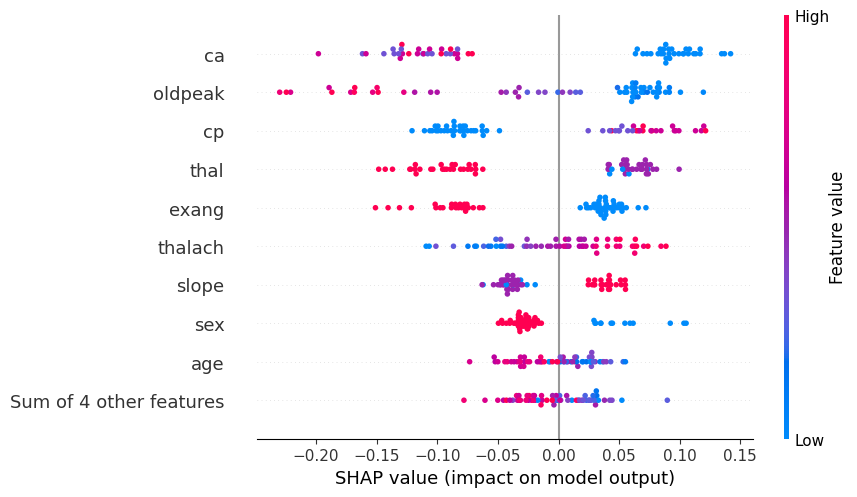

In [10]:
#SHAP
import matplotlib.pyplot as plt
import shap


fig = plt.figure()
# Create explainer
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values[:, :, 1], show=False)



In [11]:
fig.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.close(fig)

In [12]:
import lime
import lime.lime_tabular
import pandas as pd

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=["No Disease", "Disease"],
    mode="classification"
)

instance = X_test.iloc[0]

def predict_fn(x):
    return model.predict_proba(pd.DataFrame(x, columns=X.columns))

exp = explainer_lime.explain_instance(
    instance.values,
    predict_fn
)

exp.save_to_file("lime_output.html")

In [13]:
#save model properly
import pickle

pickle.dump(model, open("model.pkl", "wb"))